# Class-Incremental Continual Learning on Split-MNIST

### A Comparative Study of FeCAM and Experience Replay

This notebook presents a comparison of the FeCAM algorithm from the literatire with the well
known replay based approach in a class incremental setting. In additon we also present an ablation study 
of the FeCAM method.

**Problem setting.** In *class-incremental* continual learning a single model must learn a
sequence of tasks, where each task introduces a disjoint set of new classes. At test time
the task identity is *not* available, so the model has to discriminate between every class
seen so far. The central difficulty is *catastrophic forgetting*: naively fine-tuning on the
newest task overwrites the representations needed for earlier ones.

**What this study compares.** Two contrasting families of continual-learning methods are
evaluated under identical conditions on the Split-MNIST benchmark:

1. **FeCAM** — a *non-exemplar*, prototype-based method that stores only class statistics
   (means and covariances) of the different classes and makes prediction using the Mahalanobis distance. 
   It keeps no raw images and is therefore privacy preserving. The method follows
   Goswami *et al.*, *"FeCAM: Exploiting the Heterogeneity of Class Distributions in
   Exemplar-Free Continual Learning"*, NeurIPS 2023
   ([paper](https://proceedings.neurips.cc/paper_files/paper/2023/file/15294ba2dcfb4521274f7aa1c26f4dd4-Paper-Conference.pdf)).
2. **Experience Replay (ER)** — the standard *rehearsal* baseline that retains a small,
   fixed-size buffer of past raw samples and interleaves them with the current task. Two
   memory budgets are studied (500 and 100 samples) to probe how performance scales with the
   amount of stored data.

**Benchmark.** Split-MNIST partitions the ten MNIST digit classes into five sequential
tasks of two classes each: `(0,1) → (2,3) → (4,5) → (6,7) → (8,9)`. After every task the
model is evaluated on *all* classes encountered up to that point, which exposes both forward
learning and backward forgetting.

**Outputs.** Running the notebook end-to-end produces the following artefacts, each written
to a dedicated directory:

| Directory   | Contents                                                            |
|-------------|---------------------------------------------------------------------|
| `models/`   | the frozen feature extractor (`fmnist_pretrained.pth`)              |
| `figures/`  | confusion-matrix grids and the final accuracy comparison plot       |
| `results/`  | `metrics.txt`, a plain-text report of all accuracy numbers          |

## 1. Environment and configuration

All experiment-wide settings live in this section so that the rest of the notebook contains
no hard-coded magic numbers. Output directories are created up front and every artefact is
later written relative to these paths.

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
warnings.filterwarnings("ignore")

In [2]:
# --- Reproducibility 
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Seed every source of randomness so that runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT_DIR    = Path(".").resolve()
DATA_DIR    = ROOT_DIR / "data"      
MODELS_DIR  = ROOT_DIR / "models"    # frozen feature extractor
FIGURES_DIR = ROOT_DIR / "figures"   # all plots
RESULTS_DIR = ROOT_DIR / "results"   # textual metrics report
for d in (DATA_DIR, MODELS_DIR, FIGURES_DIR, RESULTS_DIR):
    d.mkdir(exist_ok=True)

PRETRAINED_PATH = MODELS_DIR / "fmnist_pretrained.pth"

# --- Benchmark and training hyper-parameters 
CLASS_SPLITS    = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]] 
TASK_LABELS     = ["(0,1)", "(2,3)", "(4,5)", "(6,7)", "(8,9)"]
NUM_CLASSES     = 10
FEATURE_DIM     = 128      

PRETRAIN_EPOCHS = 40        # epochs for the feature-extractor pre-training
REPLAY_EPOCHS   = 5         # epochs per task for Experience Replay
BUFFER_SIZES    = [500, 100]

print(f"Using device: {DEVICE}")

Using device: cuda


## 2. The Split-MNIST benchmark

Two datasets are used, each consisting of 28×28 single-channel images:

* **Fashion-MNIST (FMNIST)** is used *only* to pre-train the feature extractor for FeCAM.
  Training the backbone on a related-but-disjoint dataset mimics the realistic setting where
  a generic encoder is available before the continual-learning stream begins, and it prevents
  the encoder from having privileged knowledge of the MNIST evaluation classes.
* **MNIST** is the continual-learning benchmark. Its ten digit classes are split into the
  five sequential two-class tasks defined by `CLASS_SPLITS`.

Pixels are normalised to `[-1, 1]`, which keeps the pre-trained encoder and the
replay model on a consistent input scale.

In [3]:
# Shared pre-processing: tensor conversion followed by mean/std normalisation to ~[-1, 1].
TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


def load_fashion_mnist():
    """Return the (train, test) Fashion-MNIST datasets used for backbone pre-training."""
    train = datasets.FashionMNIST(DATA_DIR, train=True,  download=True, transform=TRANSFORM)
    test  = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=TRANSFORM)
    return train, test


def load_mnist():
    """Return the (train, test) MNIST datasets used for the continual-learning experiments."""
    train = datasets.MNIST(DATA_DIR, train=True,  download=True, transform=TRANSFORM)
    test  = datasets.MNIST(DATA_DIR, train=False, download=True, transform=TRANSFORM)
    return train, test


def split_into_tasks(dataset):
    """split the dataset into the sequence of two-class."""
    targets = dataset.targets.numpy()
    tasks = []
    for class_pair in CLASS_SPLITS:
        indices = np.concatenate([np.flatnonzero(targets == c) for c in class_pair])
        tasks.append(Subset(dataset, indices.tolist()))
    return tasks

## 3. Feature extractor for FeCAM

FeCAM never updates the backbone during continual
learning. We therefore train a small convolutional encoder once on Fashion-MNIST and then
freeze it. The network maps a 28×28 image to a 128-dimensional embedding.
Normalising the embeddings places every feature vector on the unit hypersphere, which makes
the per-class covariance estimates better conditioned and the Mahalanobis distances
comparable across classes.

During pre-training a throwaway linear classification head is attached on top of the encoder
so the backbone can be optimised with a standard cross-entropy objective; the head is
discarded afterwards and only the encoder weights are kept.

In [4]:
class FeatureExtractor(nn.Module):
    """Convolutional encoder producing embeddings for FeCAM.

    Three convolutional blocks progressively widen the channel dimension (32 → 64 → 128)
    while spatial pooling reduces resolution; an adaptive average pool collapses the feature
    map to a single vector that a linear layer projects to ``feature_dim``.
    """

    def __init__(self, feature_dim: int = FEATURE_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, feature_dim)

    def forward(self, x):
        h = self.features(x).flatten(1)
        return h

In [5]:
def pretrain_feature_extractor(epochs: int = PRETRAIN_EPOCHS) -> FeatureExtractor:
    """Pre-train the encoder on Fashion-MNIST and save its weights to ``models/``.
    """
    encoder = FeatureExtractor().to(DEVICE)

    if PRETRAINED_PATH.exists():
        encoder.load_state_dict(torch.load(PRETRAINED_PATH, map_location=DEVICE))
        encoder.eval()
        return encoder

    train_ds, _ = load_fashion_mnist()
    loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    # Temporary linear head, used only to supply a training signal for the backbone.
    head = nn.Linear(FEATURE_DIM, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(list(encoder.parameters()) + list(head.parameters()), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"Pre-training feature extractor on Fashion-MNIST for {epochs} epochs")
    encoder.train()
    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            loss = criterion(head(encoder(images)), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"  epoch {epoch:2d}/{epochs}  loss = {running_loss:.3f}")

    torch.save(encoder.state_dict(), PRETRAINED_PATH)

    encoder.eval()
    return encoder


feature_extractor = pretrain_feature_extractor()

## 4. Shared plotting utility

Every method produces one confusion matrix per experience

In [6]:
def plot_confusion_grid(matrices, title, cmap, filename):
    """plot the per-experience confusion matrices.
    """
    fig, axes = plt.subplots(1, len(matrices), figsize=(18, 4))
    for exp_id, (ax, cm) in enumerate(zip(axes, matrices)):
        sns.heatmap(cm, ax=ax, cmap=cmap, cbar=(exp_id == len(matrices) - 1), square=True)
        ax.set_title(f"After experience {exp_id + 1}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    fig.tight_layout()

    save_path = FIGURES_DIR / filename
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

## 5. FeCAM

FeCAM models each class as a multivariate Gaussian in the frozen feature space. For every
class it stores a mean (prototype) and a covariance matrix; a new sample is assigned to the
class whose distribution it is closest to under the Mahalanobis distance:

$$ d_c(\mathbf{x}) = (\mathbf{x} - \boldsymbol{\mu}_c)^\top \Sigma_c^{-1} (\mathbf{x} - \boldsymbol{\mu}_c). $$

Covariance estimates from a few hundred samples are noisy and often singular, so a simple
shrinkage regulariser is applied: a scaled identity is added to the empirical covariance,
which guarantees invertibility and stabilises the distance. Because only these statistics are
retained, never raw images, FeCAM is *exemplar-free* and privacy preserving.

In [ ]:
class FeCAM:
    """

    Class statistics are accumulated incrementally: ``update`` is called once per task with
    the features of the freshly seen classes, leaving previously stored statistics untouched.

    The covariance model is controlled by ``cov_type`` and is the subject of the ablation in
    Section 5.3:

    ``"full"``     full empirical covariance  -> genuine Mahalanobis distance;
    ``"diagonal"`` per-dimension variances only (off-diagonal terms dropped);
    ``"identity"`` unit covariance, which reduces the distance to plain squared Euclidean,
      i.e. a nearest-class-mean (NCM) baseline.
    """

    def __init__(self, shrinkage: float = 1.0, cov_type: str = "full"):
        if cov_type not in {"full", "diagonal", "identity"}:
            raise ValueError(f"unknown cov_type: {cov_type!r}")
        self.shrinkage = shrinkage
        self.cov_type = cov_type
        self.means = {}  # class label -> mean feature vector
        self.covs = {}   # class label -> regularised covariance matrix

    def _shrink(self, cov):
        """Add a scaled identity so the covariance stays well-conditioned and invertible."""
        return cov + self.shrinkage * np.mean(np.diag(cov)) * np.eye(cov.shape[0])

    def _estimate_cov(self, class_feats):
        """Build the per-class covariance according to ``cov_type``, then apply shrinkage."""
        dim = class_feats.shape[1]
        if self.cov_type == "identity":
            return np.eye(dim)  
        if self.cov_type == "diagonal":
            cov = np.diag(class_feats.var(axis=0))
        else:  # "full"
            cov = np.cov(class_feats.T)
        return self._shrink(cov)

    def update(self, features, labels):
        """Fit a Gaussian (mean + covariance) for each class present in ``labels``."""
        for c in np.unique(labels):
            class_feats = features[labels == c]
            self.means[int(c)] = class_feats.mean(axis=0)
            self.covs[int(c)] = self._estimate_cov(class_feats)

    def predict(self, features):
        """Assign each row of ``features`` to the nearest class by Mahalanobis distance."""
        classes = sorted(self.means.keys())
        distances = []
        for c in classes:
            diff = features - self.means[c]
            precision = np.linalg.pinv(self.covs[c])  # pseudo-inverse for numerical safety
            distances.append(np.sum((diff @ precision) * diff, axis=1))
        distances = np.stack(distances)
        return np.array(classes)[np.argmin(distances, axis=0)]

### 5.1 Training and evaluation

For each task the frozen encoder turns the task's images into features, from which FeCAM
estimates the class Gaussians. The model is then evaluated on every class seen so far, and we
record both the cumulative accuracy and the full confusion matrix.

In [ ]:
@torch.no_grad()
def extract_features(encoder, dataset, batch_size=256):
    """Run ``dataset`` through the frozen encoder and return (features, labels) as arrays."""
    feats, labels = [], []
    for images, targets in DataLoader(dataset, batch_size=batch_size):
        feats.append(encoder(images.to(DEVICE)).cpu().numpy())
        labels.append(targets.numpy())
    return np.concatenate(feats), np.concatenate(labels)


def run_fecam(encoder, train_tasks, test_tasks, shrinkage=1.0, cov_type="full", verbose=True):
    """Train FeCAM over the task sequence, returning per-experience accuracies and matrices.
    """
    fecam = FeCAM(shrinkage=shrinkage, cov_type=cov_type)
    accuracies, conf_matrices = [], []

    for task_id, task in enumerate(train_tasks):
        # Fit Gaussians for the classes introduced by this task.
        feats, labels = extract_features(encoder, task)
        fecam.update(feats, labels)

        # Evaluate on every experience seen so far (0 ... task_id).
        all_preds, all_labels = [], []
        for t in range(task_id + 1):
            feats_t, labels_t = extract_features(encoder, test_tasks[t])
            all_preds.extend(fecam.predict(feats_t))
            all_labels.extend(labels_t)

        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        acc = (all_preds == all_labels).mean()
        accuracies.append(acc)
        conf_matrices.append(confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES)))
        if verbose:
            print(f"Experience {task_id + 1} | classes {CLASS_SPLITS[task_id]} | "
                  f"cumulative accuracy = {acc:.4f}")

    return accuracies, conf_matrices


# Build the Split-MNIST task streams once and reuse them for every method.
mnist_train, mnist_test = load_mnist()
train_tasks = split_into_tasks(mnist_train)
test_tasks  = split_into_tasks(mnist_test)

acc_fecam, cm_fecam = run_fecam(feature_extractor, train_tasks, test_tasks)

Experience 1 | classes [0, 1] | cumulative accuracy = 0.9570
Experience 2 | classes [2, 3] | cumulative accuracy = 0.7931
Experience 3 | classes [4, 5] | cumulative accuracy = 0.7246
Experience 4 | classes [6, 7] | cumulative accuracy = 0.7323
Experience 5 | classes [8, 9] | cumulative accuracy = 0.7026


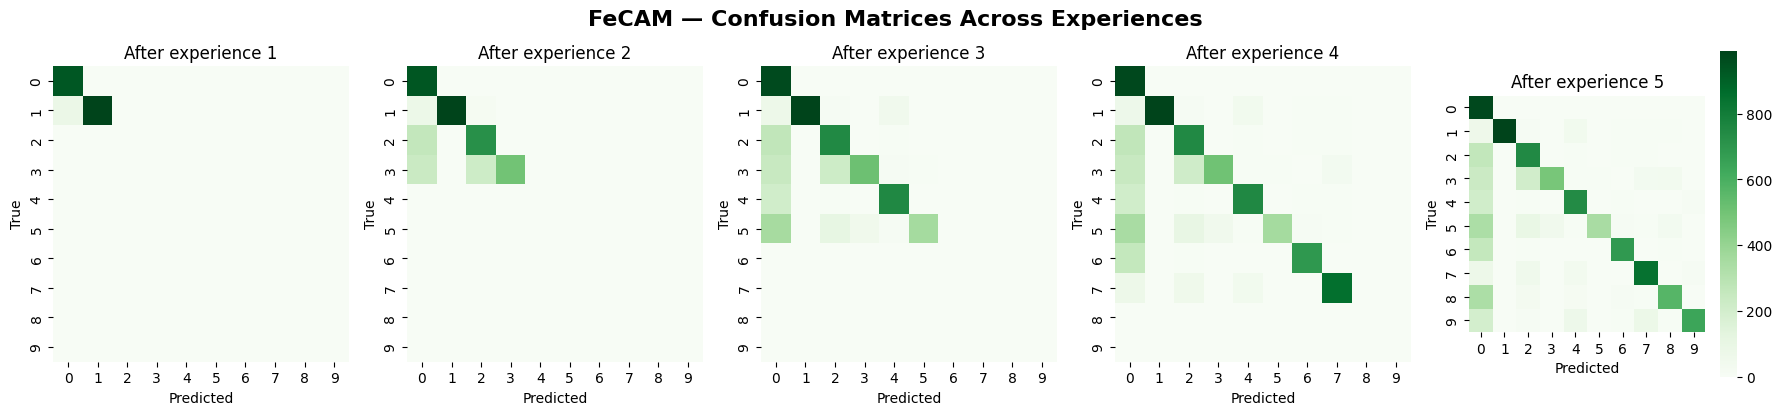

In [9]:
plot_confusion_grid(
    cm_fecam,
    title="FeCAM — Confusion Matrices Across Experiences",
    cmap="Greens",
    filename="fecam_confusion_matrices.png",
)

### 5.3 Ablation study: covariance model

FeCAM's behaviour hinges on how each class distribution is modelled in the frozen feature
space. To isolate the contribution of the covariance estimate, we re-run the full Split-MNIST
protocol under three choices of `cov_type` while keeping every other setting fixed:

* `identity` — unit covariance, so the Mahalanobis distance collapses to Euclidean distance.
* `diagonal` — per-dimension variances only; cheap, but blind to feature correlations.
* `full` — the complete empirical covariance, i.e. the genuine Mahalanobis classifier.

For each covariance model we report the accuracy after every experience together with
the mean accuracy across experiences. Results are tabulated, written to
`results/fecam_ablation.txt`, and visualised in `figures/fecam_ablation.png`.

In [10]:
# Covariance models to compare
COV_TYPES = ["identity", "diagonal", "full"]

ablation_results = []
for cov_type in COV_TYPES:
    accs, _ = run_fecam(
        feature_extractor, train_tasks, test_tasks,
        cov_type=cov_type,
        verbose=False,
    )
    ablation_results.append({"cov_type": cov_type, "accuracies": accs})
    pct = np.array(accs) * 100
    per_experience = "  ".join(f"{lbl}={v:.2f}" for lbl, v in zip(TASK_LABELS, pct))
    print(f"cov_type={cov_type:8s} | {per_experience} | mean={pct.mean():.2f}%")

cov_type=identity | (0,1)=84.96  (2,3)=70.46  (4,5)=64.15  (6,7)=55.69  (8,9)=51.45 | mean=65.34%
cov_type=diagonal | (0,1)=90.64  (2,3)=65.86  (4,5)=58.30  (6,7)=55.77  (8,9)=51.49 | mean=64.41%
cov_type=full     | (0,1)=95.70  (2,3)=79.31  (4,5)=72.46  (6,7)=73.23  (8,9)=70.26 | mean=78.19%


In [11]:
def write_ablation_report(path, results):
    header = "cov_type".ljust(12) + "".join(f"{lbl:>10}" for lbl in TASK_LABELS) + f"{'Mean':>10}"
    lines = ["FeCAM Covariance-Model Ablation on Split-MNIST",
             "=" * len(header), "",
             "Accuracy (%) after each experience and averaged across experiences", "",
             header, "-" * len(header)]
    for r in results:
        pct = np.array(r["accuracies"]) * 100
        lines.append(r["cov_type"].ljust(12)
                     + "".join(f"{v:>10.2f}" for v in pct)
                     + f"{pct.mean():>10.2f}")
    report = "\n".join(lines)
    Path(path).write_text(report)
    print(report)


write_ablation_report(RESULTS_DIR / "fecam_ablation.txt", ablation_results)

FeCAM Covariance-Model Ablation on Split-MNIST

Accuracy (%) after each experience and averaged across experiences

cov_type         (0,1)     (2,3)     (4,5)     (6,7)     (8,9)      Mean
------------------------------------------------------------------------
identity         84.96     70.46     64.15     55.69     51.45     65.34
diagonal         90.64     65.86     58.30     55.77     51.49     64.41
full             95.70     79.31     72.46     73.23     70.26     78.19


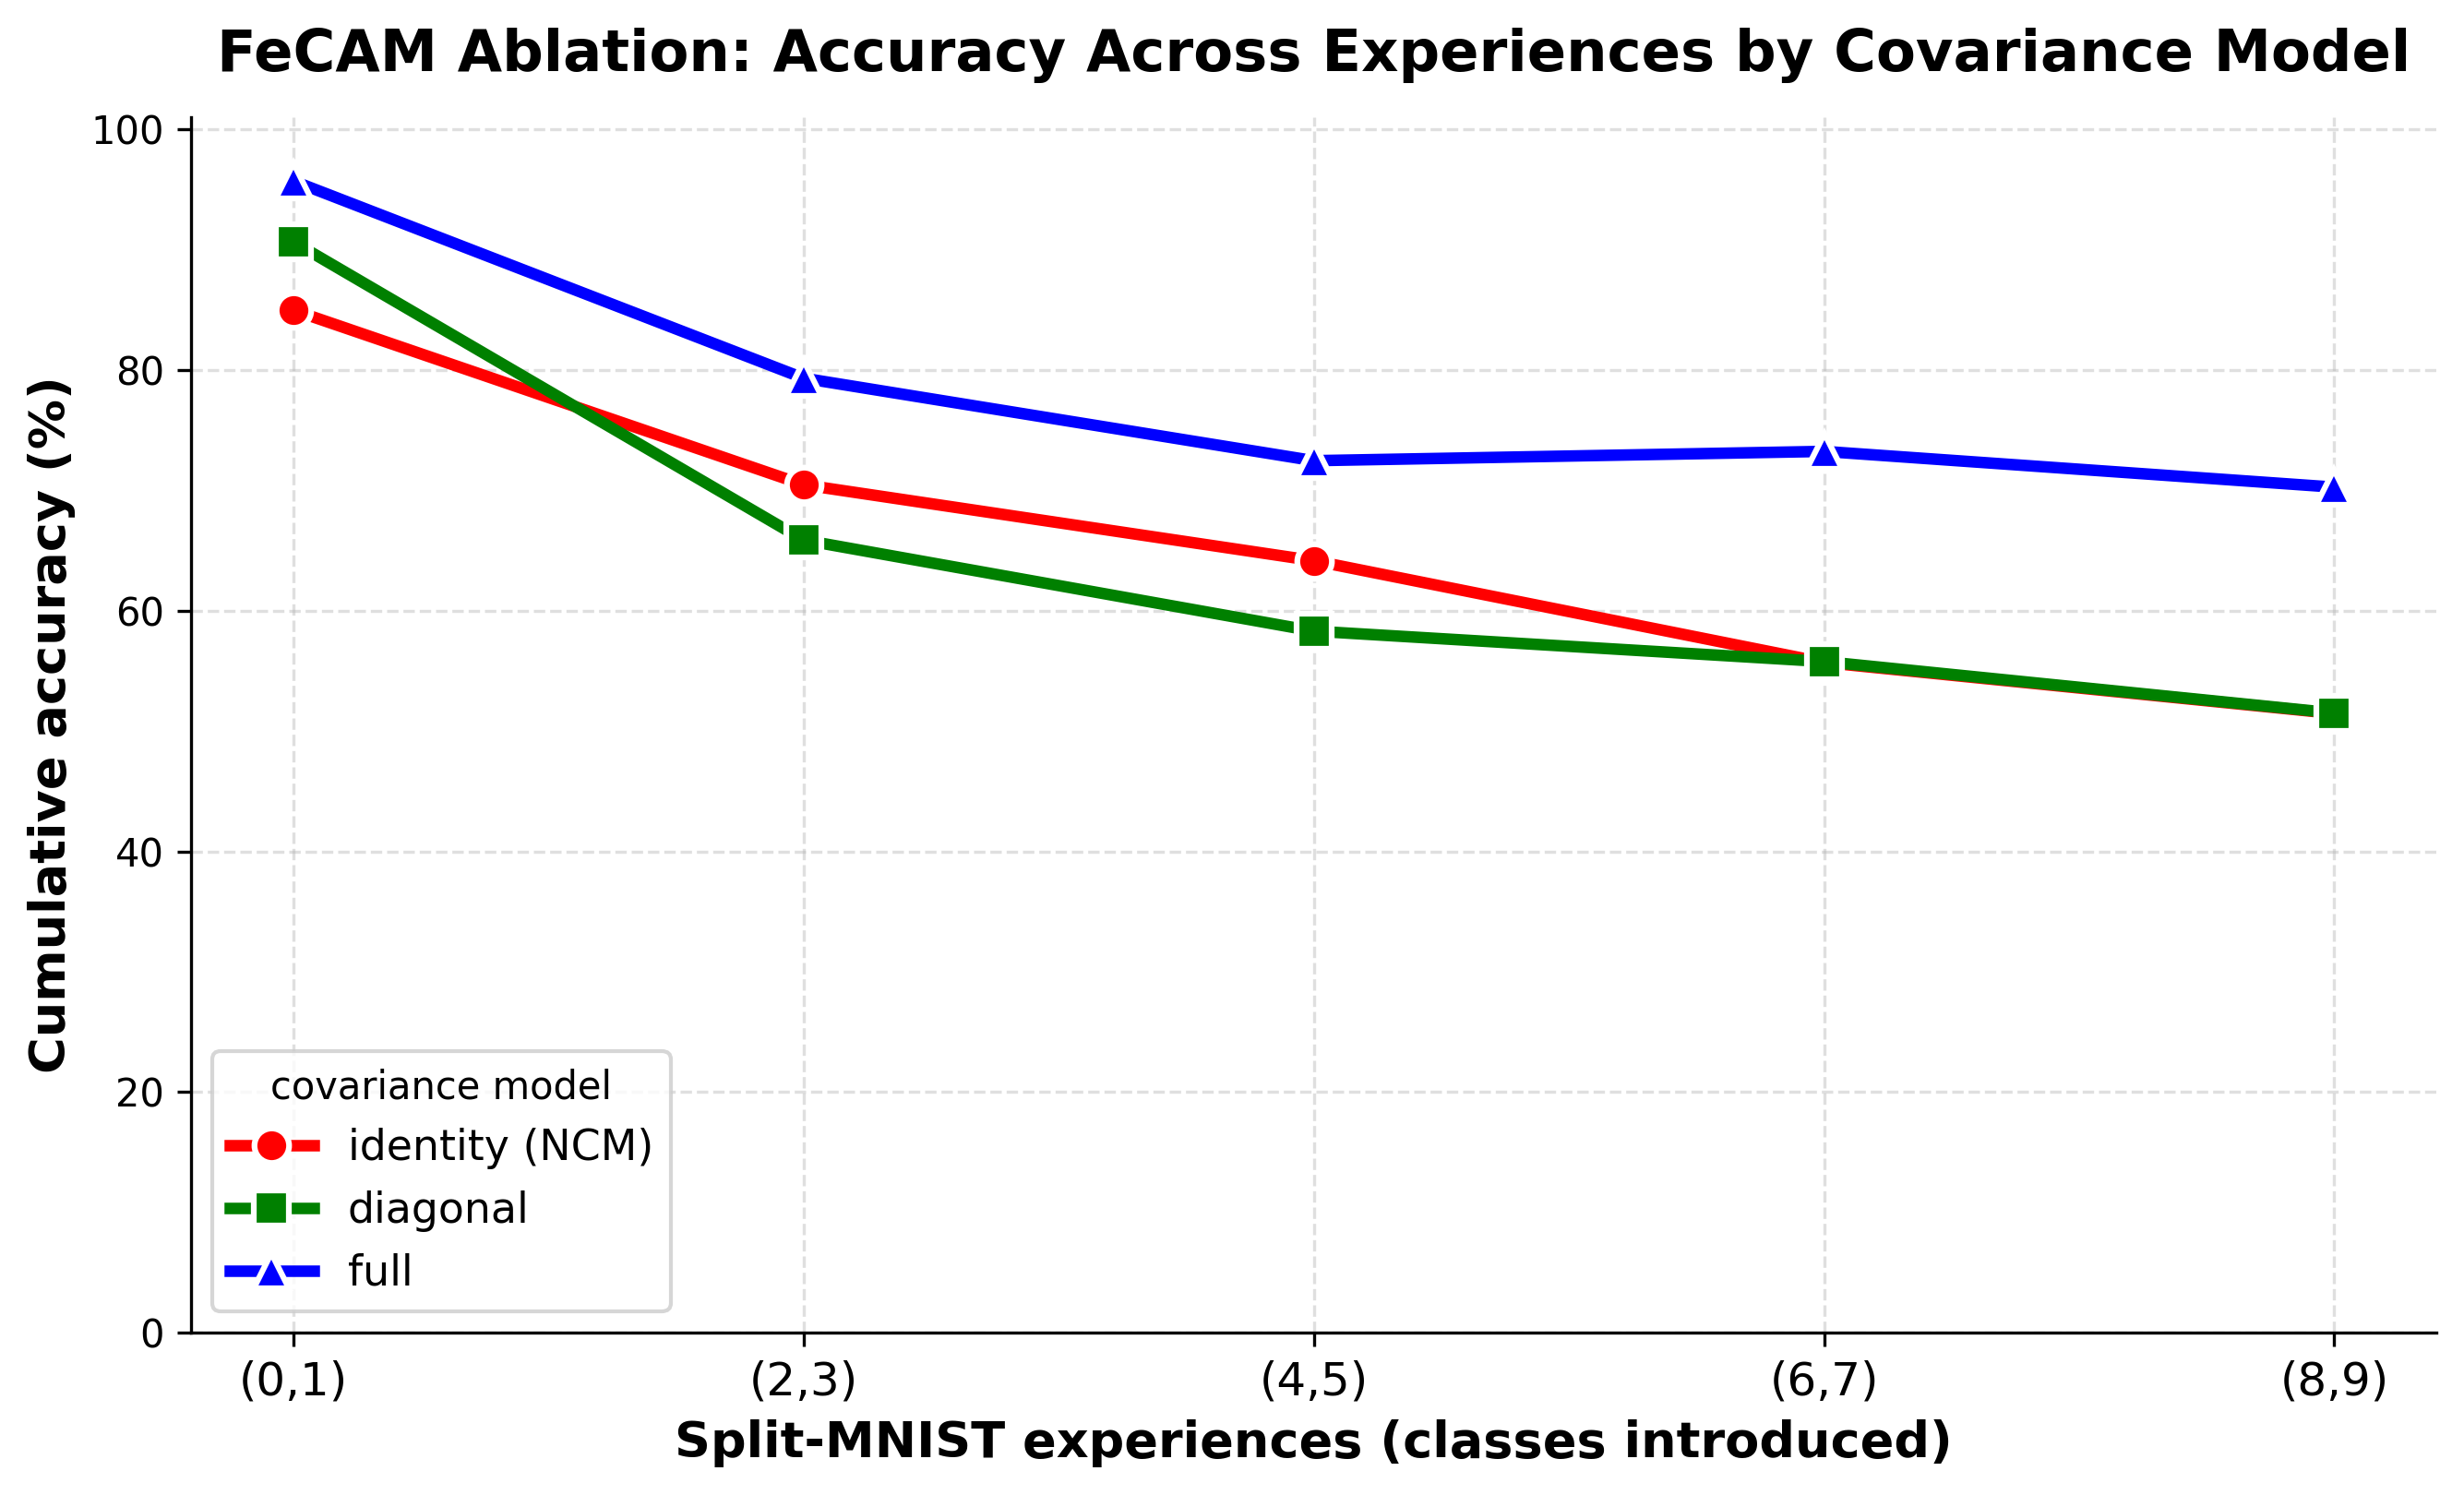

In [12]:
# Visualise the sweep: accuracy across experiences, one curve per covariance model.
x = np.arange(len(TASK_LABELS))
palette = {"identity": "red", "diagonal": "green", "full": "blue"}
markers = {"identity": "o", "diagonal": "s", "full": "^"}

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)
for r in ablation_results:
    pct = np.array(r["accuracies"]) * 100
    label = "identity (NCM)" if r["cov_type"] == "identity" else r["cov_type"]
    ax.plot(x, pct, marker=markers[r["cov_type"]], markersize=9, linewidth=3,
            color=palette[r["cov_type"]], label=label,
            markeredgecolor="white", markeredgewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(TASK_LABELS, fontsize=12)
ax.set_xlabel("Split-MNIST experiences (classes introduced)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative accuracy (%)", fontsize=13, fontweight="bold")
ax.set_title("FeCAM Ablation: Accuracy Across Experiences by Covariance Model",
             fontsize=15, fontweight="bold", pad=12)
ax.set_ylim(0, 101)
ax.grid(linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="covariance model", fontsize=11, loc="lower left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fecam_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Experience Replay

Experience Replay confronts forgetting directly: it keeps a small buffer of past raw samples
and mixes them into every training batch, so that while leanring new tasks, the decision boundary 
does not get biased and completely move towards the newly learned classes. Unlike FeCAM, the backbone here is trained
end-to-end as new tasks arrive.

### 6.1 Reservoir-sampling buffer

Because the data stream is of unknown length and memory is bounded, the buffer is maintained
with *reservoir sampling*. This guarantess that each sample has the possibilty of being picked
during the training of the new classes with almost the same probability

In [13]:
class ReservoirBuffer:
    """Fixed-capacity replay memory maintained by reservoir sampling.
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.images = []
        self.labels = []
        self.n_seen = 0

    def add_batch(self, images, labels):
        """Offer a batch of (image, label) pairs to the reservoir."""
        for img, lab in zip(images, labels):
            self.n_seen += 1
            if len(self.images) < self.capacity:
                self.images.append(img.cpu())
                self.labels.append(lab.cpu())
            else:
                j = random.randint(0, self.n_seen - 1)
                if j < self.capacity:
                    self.images[j] = img.cpu()
                    self.labels[j] = lab.cpu()

    def sample(self, batch_size):
        """Draw up to ``batch_size`` stored samples; returns (None, None) when empty."""
        if not self.images:
            return None, None
        idx = random.sample(range(len(self.images)), min(batch_size, len(self.images)))
        images = torch.stack([self.images[i] for i in idx])
        labels = torch.stack([self.labels[i] for i in idx])
        return images, labels

### 6.2 Replay model and training loop

A compact CNN classifier is trained over the task stream. Each task is learned for a few
epochs; in every step the current mini-batch is augmented with an equally sized sample drawn
from the buffer, and only after the task is finished is the buffer refreshed with the task's
data. The whole procedure is parameterised by the buffer capacity so the two memory budgets
share a single, well-tested implementation.

In [14]:
class ReplayCNN(nn.Module):
    """Small convolutional classifier trained end-to-end under Experience Replay."""

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256), nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def run_experience_replay(buffer_size, train_tasks, test_tasks, epochs=REPLAY_EPOCHS):

    set_seed()  # identical initialisation for every buffer size -> a fair comparison
    model = ReplayCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    buffer = ReservoirBuffer(buffer_size)

    accuracies, conf_matrices = [], []

    for task_id, task in enumerate(train_tasks):
        loader = DataLoader(task, batch_size=64, shuffle=True)

        # --- Learn the current task, rehearsing buffered samples each step ---
        model.train()
        for epoch in range(1, epochs + 1):
            running_loss = 0.0
            for images, labels in loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                # Interleave a replay batch from previous tasks (if any are stored yet).
                replay_images, replay_labels = buffer.sample(64)
                if replay_images is not None:
                    images = torch.cat([images, replay_images.to(DEVICE)])
                    labels = torch.cat([labels, replay_labels.to(DEVICE)])

                loss = criterion(model(images), labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            print(f"  epoch {epoch}/{epochs}  loss = {running_loss:.3f}")

        # --- Refresh the reservoir with this task's data, then evaluate ---
        for images, labels in loader:
            buffer.add_batch(images, labels)

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for t in range(task_id + 1):
                for images, labels in DataLoader(test_tasks[t], batch_size=256):
                    preds = model(images.to(DEVICE)).argmax(1).cpu().numpy()
                    all_preds.extend(preds)
                    all_labels.extend(labels.numpy())

        all_preds, all_labels = np.array(all_preds), np.array(all_labels)
        acc = (all_preds == all_labels).mean()
        accuracies.append(acc)
        conf_matrices.append(confusion_matrix(all_labels, all_preds, labels=np.arange(NUM_CLASSES)))
        print(f"Experience {task_id + 1} | classes {CLASS_SPLITS[task_id]} | "
              f"cumulative accuracy = {acc:.4f}\n")

    return accuracies, conf_matrices, buffer


def buffer_class_distribution(buffer):
    """Print how many stored samples belong to each class, exposing the buffer's balance."""
    classes, counts = np.unique([int(l) for l in buffer.labels], return_counts=True)
    print(f"Buffer occupancy ({len(buffer.labels)}/{buffer.capacity} samples):")
    for label, count in zip(classes, counts):
        print(f"  class {label}: {count} samples")

### 6.3 Experience Replay with a 500-sample buffer

In [15]:
print("Experience Replay — buffer size 500")
acc_er500, cm_er500, buffer500 = run_experience_replay(500, train_tasks, test_tasks)
buffer_class_distribution(buffer500)

Experience Replay — buffer size 500
  epoch 1/5  loss = 9.028
  epoch 2/5  loss = 0.675
  epoch 3/5  loss = 0.316
  epoch 4/5  loss = 0.291
  epoch 5/5  loss = 0.280
Experience 1 | classes [0, 1] | cumulative accuracy = 1.0000

  epoch 1/5  loss = 29.526
  epoch 2/5  loss = 2.158
  epoch 3/5  loss = 1.660
  epoch 4/5  loss = 0.950
  epoch 5/5  loss = 0.634
Experience 2 | classes [2, 3] | cumulative accuracy = 0.9925

  epoch 1/5  loss = 75.394
  epoch 2/5  loss = 1.438
  epoch 3/5  loss = 0.669
  epoch 4/5  loss = 0.392
  epoch 5/5  loss = 0.185
Experience 3 | classes [4, 5] | cumulative accuracy = 0.9798

  epoch 1/5  loss = 82.253
  epoch 2/5  loss = 1.383
  epoch 3/5  loss = 0.604
  epoch 4/5  loss = 0.334
  epoch 5/5  loss = 0.191
Experience 4 | classes [6, 7] | cumulative accuracy = 0.9547

  epoch 1/5  loss = 107.656
  epoch 2/5  loss = 8.371
  epoch 3/5  loss = 5.340
  epoch 4/5  loss = 3.732
  epoch 5/5  loss = 2.897
Experience 5 | classes [8, 9] | cumulative accuracy = 0.9349


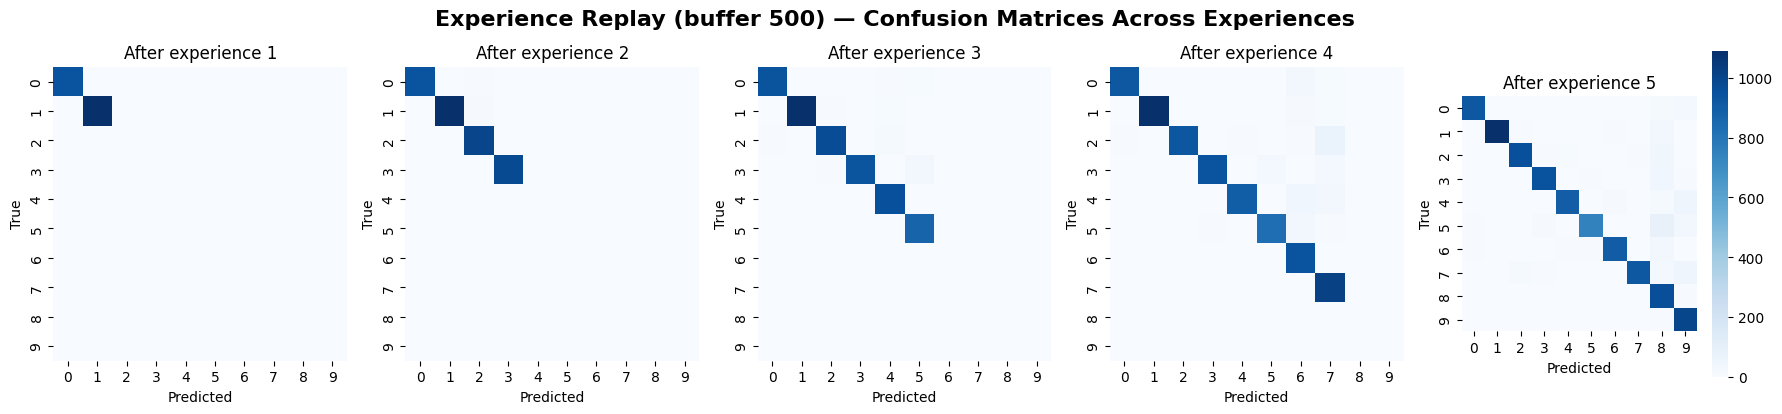

In [16]:
plot_confusion_grid(
    cm_er500,
    title="Experience Replay (buffer 500) — Confusion Matrices Across Experiences",
    cmap="Blues",
    filename="experience_replay_500_confusion_matrices.png",
)

### 6.4 Experience Replay with a 100-sample buffer

Shrinking the buffer five-fold tests how rehearsal degrades when very little past
data can be retained.

In [17]:
print("Experience Replay — buffer size 100")
acc_er100, cm_er100, buffer100 = run_experience_replay(100, train_tasks, test_tasks)
buffer_class_distribution(buffer100)

Experience Replay — buffer size 100
  epoch 1/5  loss = 9.030
  epoch 2/5  loss = 0.705
  epoch 3/5  loss = 0.305
  epoch 4/5  loss = 0.253
  epoch 5/5  loss = 0.264
Experience 1 | classes [0, 1] | cumulative accuracy = 1.0000

  epoch 1/5  loss = 27.974
  epoch 2/5  loss = 1.951
  epoch 3/5  loss = 1.311
  epoch 4/5  loss = 0.961
  epoch 5/5  loss = 0.560
Experience 2 | classes [2, 3] | cumulative accuracy = 0.9832

  epoch 1/5  loss = 70.208
  epoch 2/5  loss = 1.960
  epoch 3/5  loss = 1.166
  epoch 4/5  loss = 0.931
  epoch 5/5  loss = 0.723
Experience 3 | classes [4, 5] | cumulative accuracy = 0.9063

  epoch 1/5  loss = 95.899
  epoch 2/5  loss = 0.946
  epoch 3/5  loss = 0.469
  epoch 4/5  loss = 0.274
  epoch 5/5  loss = 0.176
Experience 4 | classes [6, 7] | cumulative accuracy = 0.8916

  epoch 1/5  loss = 107.067
  epoch 2/5  loss = 2.832
  epoch 3/5  loss = 1.925
  epoch 4/5  loss = 1.249
  epoch 5/5  loss = 0.986
Experience 5 | classes [8, 9] | cumulative accuracy = 0.7948


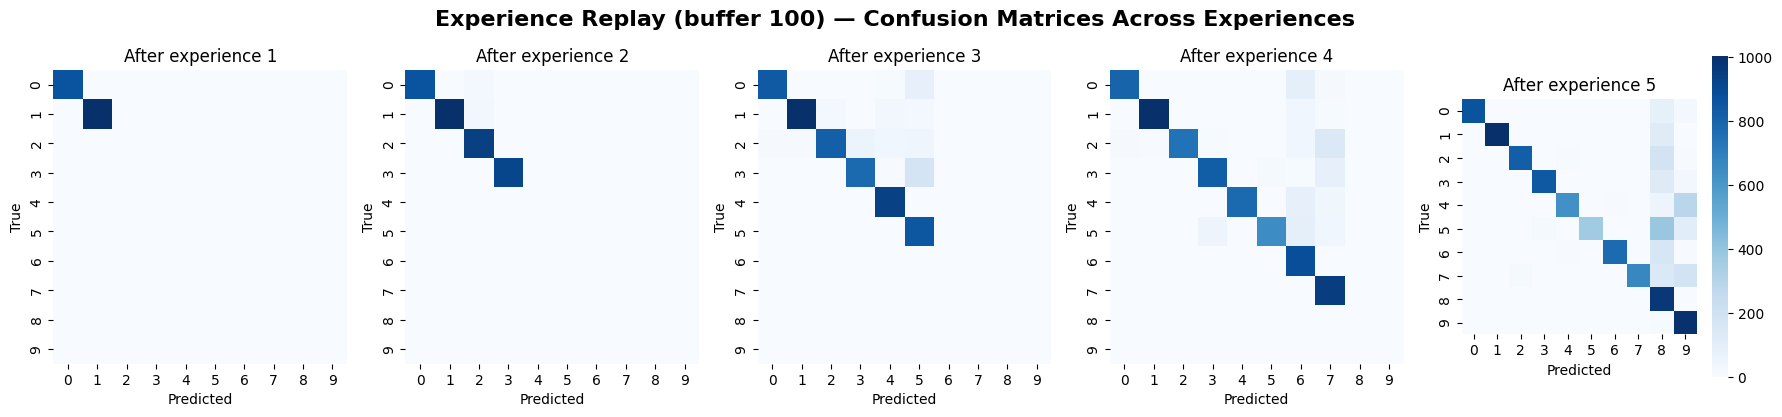

In [18]:
plot_confusion_grid(
    cm_er100,
    title="Experience Replay (buffer 100) — Confusion Matrices Across Experiences",
    cmap="Blues",
    filename="experience_replay_100_confusion_matrices.png",
)

## 7. Results

### 7.1 Accuracy across experiences

The figure below traces the cumulative accuracy of all three configurations as the five
experiences are learned in turn. A flat, high curve indicates effective resistance to
forgetting; a downward slope reveals accuracy being lost on earlier classes as new ones are
added.

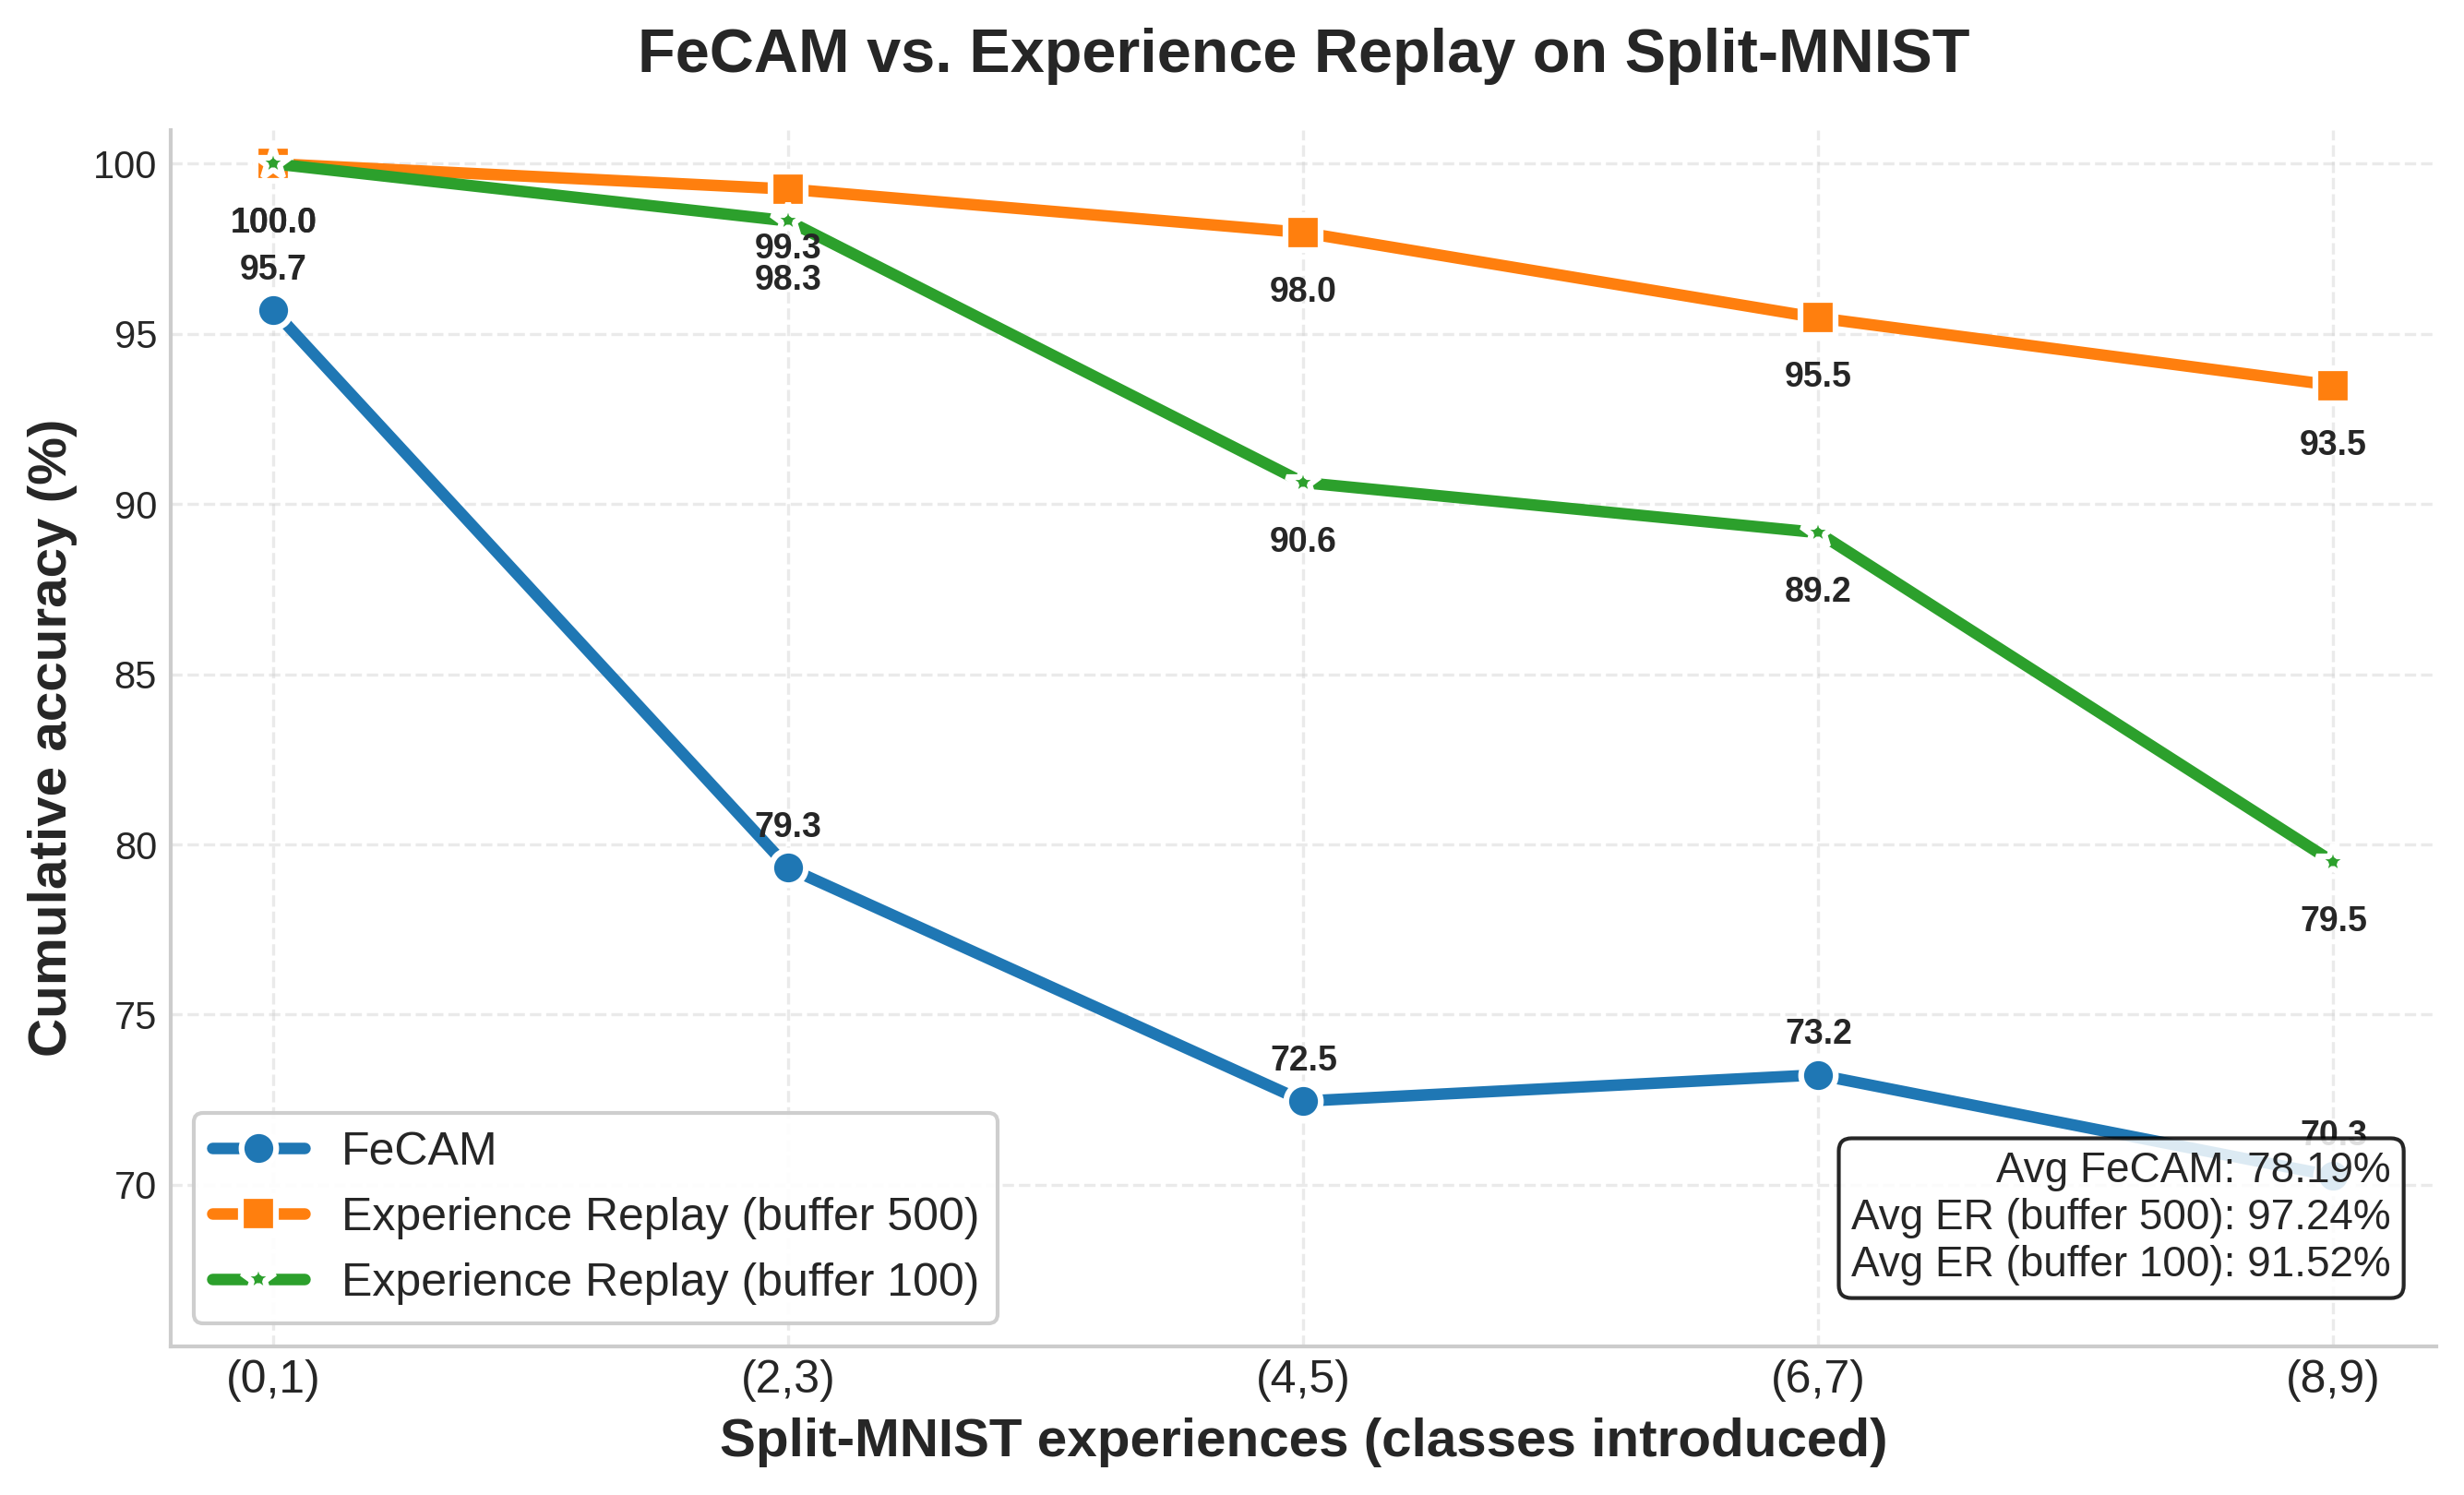

In [24]:
# Convert the stored fractions to percentages for plotting and reporting.
acc_fecam_pct = np.array(acc_fecam) * 100
acc_er500_pct = np.array(acc_er500) * 100
acc_er100_pct = np.array(acc_er100) * 100

x = np.arange(len(TASK_LABELS))

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=300)

series = [
    (acc_fecam_pct, "o", "FeCAM", 8),
    (acc_er500_pct, "s", "Experience Replay (buffer 500)", -18),
    (acc_er100_pct, "*", "Experience Replay (buffer 100)", -18),
]
for values, marker, label, y_offset in series:
    ax.plot(x, values, marker=marker, markersize=9, linewidth=3, label=label,
            markeredgecolor="white", markeredgewidth=1.5)
    for xi, vi in zip(x, values):
        ax.annotate(f"{vi:.1f}", (xi, vi), textcoords="offset points",
                    xytext=(0, y_offset), ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(TASK_LABELS, fontsize=12)
ax.set_xlabel("Split-MNIST experiences (classes introduced)", fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative accuracy (%)", fontsize=14, fontweight="bold")
ax.set_title("FeCAM vs. Experience Replay on Split-MNIST", fontsize=16, fontweight="bold", pad=15)
ax.grid(linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(fontsize=12, frameon=True, loc="lower left")
legend.get_frame().set_alpha(0.95)

ax.set_ylim(max(0, min(acc_fecam_pct.min(), acc_er500_pct.min(), acc_er100_pct.min()) - 5), 101)

summary = (f"Avg FeCAM: {acc_fecam_pct.mean():.2f}%\n"
           f"Avg ER (buffer 500): {acc_er500_pct.mean():.2f}%\n"
           f"Avg ER (buffer 100): {acc_er100_pct.mean():.2f}%")
ax.text(0.98, 0.05, summary, transform=ax.transAxes, fontsize=11,
        va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fecam_vs_er_publication.png", dpi=600, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "fecam_vs_er_publication.pdf", bbox_inches="tight")
plt.show()

### 7.2 Quantitative report


In [23]:
def write_metrics_report(path, results):
    lines = ["Continual Learning on Split-MNIST — Accuracy Report",
             "=" * 55, ""]
    header = "Experience".ljust(14) + "".join(f"{lbl:>10}" for lbl in TASK_LABELS) + f"{'Average':>10}"

    for method, accuracies in results.items():
        pct = np.array(accuracies) * 100
        lines.append(method)
        lines.append("-" * len(method))
        lines.append(header)
        lines.append("accuracy %".ljust(14)
                     + "".join(f"{v:>10.2f}" for v in pct)
                     + f"{pct.mean():>10.2f}")
        lines.append("")

    report = "\n".join(lines)
    Path(path).write_text(report)
    print(report)


metrics = {
    "FeCAM": acc_fecam,
    "Experience Replay (buffer 500)": acc_er500,
    "Experience Replay (buffer 100)": acc_er100,
}
write_metrics_report(RESULTS_DIR / "continual_learning_metrics.txt", metrics)

Continual Learning on Split-MNIST — Accuracy Report

FeCAM
-----
Experience         (0,1)     (2,3)     (4,5)     (6,7)     (8,9)   Average
accuracy %         95.70     79.31     72.46     73.23     70.26     78.19

Experience Replay (buffer 500)
------------------------------
Experience         (0,1)     (2,3)     (4,5)     (6,7)     (8,9)   Average
accuracy %        100.00     99.25     97.98     95.47     93.49     97.24

Experience Replay (buffer 100)
------------------------------
Experience         (0,1)     (2,3)     (4,5)     (6,7)     (8,9)   Average
accuracy %        100.00     98.32     90.63     89.16     79.48     91.52



## 8. Discussion and conclusion

On the Split-MNIST benchmark, Experience Replay clearly outperforms FeCAM in raw
accuracy across every experience. The advantage persists even when the replay budget is cut
from 500 to 100 samples: rehearsing a handful of representative old examples is enough to
keep the classifier's decision boundaries stable as new classes arrive. The confusion
matrices make the mechanism visible, ER retains strong diagonal mass on earlier digits,
whereas FeCAM accumulates more off-diagonal confusion as the class count grows.

The comparison is, however, not one-dimensional. FeCAM stores no raw data whatsoever , it
keeps only class means and covariances in a frozen feature space, which makes it a genuinely
*privacy-preserving* and memory-light alternative. In settings where retaining user data is
restricted by privacy, security, or regulatory constraints (healthcare, robotics, autonomous
and edge systems), that property can outweigh a gap in accuracy.

The practical takeaway is therefore a trade-off rather than a verdict: when maximising
accuracy is the priority and storing a small amount of past data is acceptable, Experience
Replay is the stronger choice; when data retention is prohibited, FeCAM offers a viable
exemplar-free continual-learning solution. The exact accuracy figures supporting these
statements are recorded in `results/metrics.txt`, and all figures are saved under `figures/`.